In [120]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Question 1: DCT-II

## Implementation of 2D Discrete Cosine Transform (DCT-II) Basis

In [23]:
def generate_dct_2d_basis(N):

    basis_set = np.zeros((N, N, N, N), dtype=np.float64)

    for u in range(N):
        au = np.sqrt(1.0 / N) if u == 0 else np.sqrt(2.0 / N)

        for v in range(N):
            av = np.sqrt(1.0 / N) if v == 0 else np.sqrt(2.0 / N)

            for x in range(N):
                cos_x = np.cos((np.pi * (2*x + 1) * u) / (2*N))

                for y in range(N):
                    basis_set[u, v, x, y] = (au * av * cos_x * np.cos((np.pi * (2*y + 1) * v) / (2*N)))
    return basis_set

## Visualization of DCT-II Basis Images for Different Block Sizes

In [37]:
def plot_dct_basis(N, plot_size=4):
    basis_set = generate_dct_2d_basis(N)

    fig, axes = plt.subplots(N, N, figsize=(plot_size, plot_size))

    for u in range(N):
        for v in range(N):
            axes[u, v].imshow(basis_set[u, v], cmap='gray')
            axes[u, v].axis('off')

    plt.tight_layout()
    plt.show()

### 4x4 DCT-II Basis Images

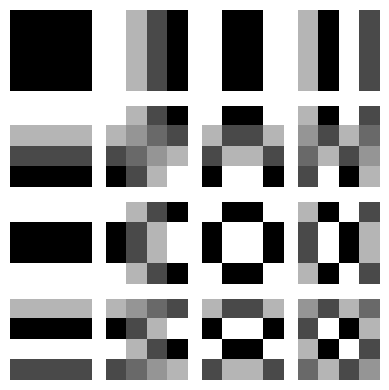

In [38]:
plot_dct_basis(4)

### 8x8 DCT-II Basis Images

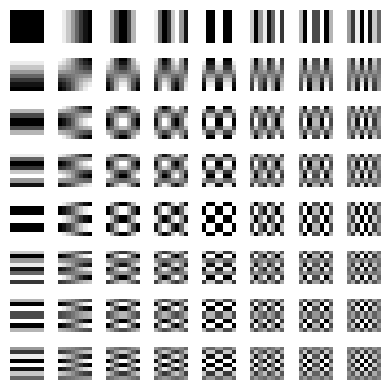

In [39]:
plot_dct_basis(8)

### 16x16 DCT-II Basis Images

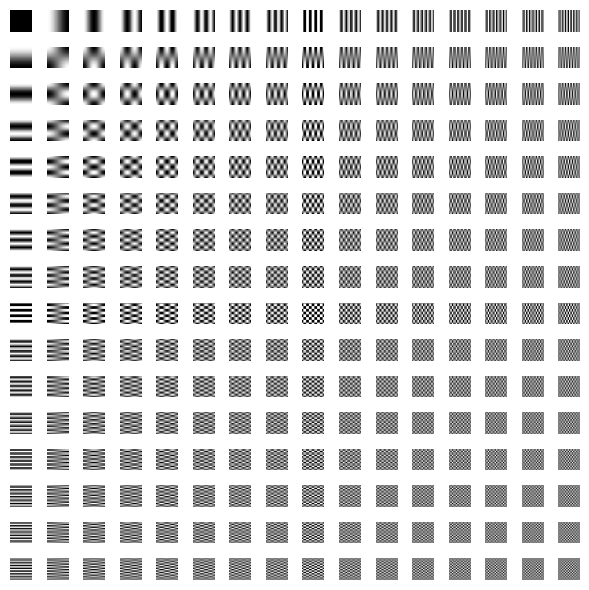

In [40]:
plot_dct_basis(16, plot_size=6)

# Question 2: DCT-based compression

## Implementation of DCT-II & IDCT-II

In [80]:
def dct(image: np.ndarray, N: int):
    u = np.arange(N).reshape(-1,1)
    x = np.arange(N).reshape(1,-1)
    alpha = lambda k: np.sqrt(1/N) if k==0 else np.sqrt(2/N)

    C = np.zeros((N,N))
    for i in range(N):
        C[i,:] = alpha(i) * np.cos(np.pi*(2*x+1)*i /(2*N))

    dct_full = C @ image @ C.T
    return dct_full


def idct(dct_coef: np.ndarray, N: int):
    u = np.arange(N).reshape(-1,1)
    x = np.arange(N).reshape(1,-1)
    alpha = lambda k: np.sqrt(1/N) if k==0 else np.sqrt(2/N)

    C = np.zeros((N,N))
    for i in range(N):
        C[i,:] = alpha(i) * np.cos(np.pi*(2*x+1)*i /(2*N))

    image = C.T @ dct_coef @ C
    return image

## PSNR Function

In [81]:
def next_power_of_two(x):
    return 1 << (x - 1).bit_length()

def my_psnr(image1: np.ndarray, image2: np.ndarray):
    if image1.shape != image2.shape:
        return -1

    max_intensity = max(image1.max(), image2.max())

    next_pow2 = next_power_of_two(int(max_intensity + 1))
    max_value = next_pow2 - 1
    max_value_sq = max_value ** 2

    mse = np.mean((image1.astype(np.float64) - image2.astype(np.float64)) ** 2)

    if mse == 0:
        return np.inf

    return 10 * np.log10(max_value_sq / mse)

## Threshold DCT Coefficients and Compute PSNR for Barbara Test Image

In [82]:
barbara_main = cv2.imread('Q_2/barbara.pgm', cv2.IMREAD_UNCHANGED)
N = barbara_main.shape[0]

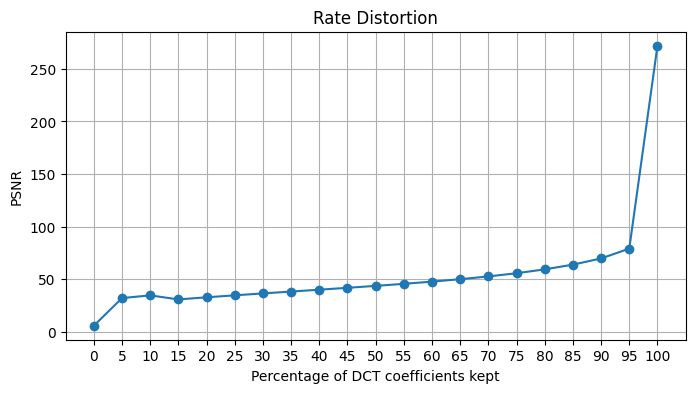

In [87]:
percentages = np.arange(0, 101, 5)
psnr_list = []

dct_full = dct(barbara_main, N)

for p in percentages:
    flat = np.abs(dct_full).flatten()
    k = int(len(flat) * p / 100)
    if k == 0:
        threshold = np.inf
    else:
        threshold = np.partition(flat, -k)[-k]


    dct_thresh = np.where(np.abs(dct_full) >= threshold, dct_full, 0)
    barbara_rec = idct(dct_thresh, N)

    file_name = f"Barbara Reconstructed/barbara_{p}_percent_coefficients.png"
    cv2.imwrite(file_name, barbara_rec)

    psnr = my_psnr(barbara_main, barbara_rec)
    psnr_list.append(psnr)


plt.figure(figsize=(8, 4))
plt.plot(percentages, psnr_list, marker='o')
plt.xlabel("Percentage of DCT coefficients kept")
plt.ylabel("PSNR")
plt.title("Rate Distortion")

plt.xticks(np.arange(0, 101, 5))
plt.grid(True)
plt.show()

# Question 3: YCbCr-based Compression

## rgb2YCbCr with 4:4:4 Mode

In [109]:
def rgb2yCbCr_444(image: np.ndarray):
    red, green, blue = image[:, :, 0], image[:, :, 1], image[:, :, 2]

    y = (0.299 * red) + (0.587 * green) + (0.114 * blue)
    Cb = (-0.168736 * red) + (-0.331264 * green) + (0.5 * blue) + 128
    Cr = (0.5 * red) + (-0.418688 * green) + (-0.081312 * blue) + 128

    yCbCr_image = np.stack([y, Cb, Cr])
    return yCbCr_image

## rgb2YCbCr with 4:2:0 Mode

In [115]:
def rgb2yCbCr_420(image: np.ndarray):
    H, W, _ = image.shape
    red, green, blue = image[:, :, 0], image[:, :, 1], image[:, :, 2]

    y = (0.299 * red) + (0.587 * green) + (0.114 * blue)
    Cb = (-0.168736 * red) + (-0.331264 * green) + (0.5 * blue) + 128
    Cr = (0.5 * red) + (-0.418688 * green) + (-0.081312 * blue) + 128

    Cb_420 = Cb[::2, ::2]
    Cr_420 = Cr[::2, ::2]

    Cb_up = np.repeat(np.repeat(Cb_420, 2, axis=0), 2, axis=1)
    Cr_up = np.repeat(np.repeat(Cr_420, 2, axis=0), 2, axis=1)

    Cb_up = Cb_up[:H, :W]
    Cr_up = Cr_up[:H, :W]

    return np.stack([y, Cb_up, Cr_up])


def yCbCr2rgb_420(YCbCr_image: np.ndarray):
    y, Cb, Cr = YCbCr_image[0], YCbCr_image[1], YCbCr_image[2]

    red = y + (1.403 * (Cr - 128))
    green = y + (-0.344 * (Cb - 128)) + (-0.714 * (Cr - 128))
    blue = y + (1.773 * (Cb - 128))

    return np.stack([red, green, blue], axis=2)

## Observation1: PSNR for Vanilla YCbCr (4:2:0) Compression

In [126]:
result1 = []

for i in range(1, 10):

    test_image = cv2.imread(f'Q_3/{i}.png')
    if i == 5:
        test_image = cv2.imread(f'Q_3/{i}.jpg')

    test_yCbCr = rgb2yCbCr_420(test_image)
    reconstructed = yCbCr2rgb_420(test_yCbCr)

    red_main = test_image[:,:, 0]
    green_main = test_image[:,:, 1]
    blue_main = test_image[:,:, 2]

    red_reconstructed = reconstructed[:,:, 0]
    green_reconstructed = reconstructed[:,:, 1]
    blue_reconstructed = reconstructed[:,:, 2]


    red_psnr = my_psnr(red_main, red_reconstructed)
    green_psnr = my_psnr(green_main, green_reconstructed)
    blue_psnr = my_psnr(blue_main, blue_reconstructed)

    avg_psnr = (red_psnr + green_psnr + blue_psnr) / 3

    result1.append({'Image Name': f"{i}.png", "Red Channel": red_psnr, "Green Channel": green_psnr, "Blue Channel": blue_psnr, "Average": avg_psnr})


result1 = pd.DataFrame(result1)
result1

,Image Name,Red Channel,Green Channel,Blue Channel,Average
0,1.png,45.588614,58.662462,51.316886,51.855987
1,2.png,43.725298,56.542978,47.409415,49.225897
2,3.png,39.300166,51.334615,42.670117,44.434966
3,4.png,34.305851,33.055501,33.884276,33.748543
4,5.png,42.105021,55.490876,50.009712,49.201870
5,6.png,44.504317,58.799619,40.835595,48.046510
6,7.png,40.763066,52.829389,45.920946,46.504467
7,8.png,40.853078,53.000295,45.870931,46.574768
8,9.png,44.166106,51.601059,42.894389,46.220518


## Observation2: PSNR for Vanilla YCbCr (4:2:0) With Gaussian Smoothing Filter

In [138]:
def rgb2yCbCr_420_second(image: np.ndarray):
    H, W, _ = image.shape
    red, green, blue = image[:, :, 0], image[:, :, 1], image[:, :, 2]

    y = (0.299 * red) + (0.587 * green) + (0.114 * blue)
    Cb = (-0.168736 * red) + (-0.331264 * green) + (0.5 * blue) + 128
    Cr = (0.5 * red) + (-0.418688 * green) + (-0.081312 * blue) + 128

    Cb_420 = Cb[::2, ::2]
    Cr_420 = Cr[::2, ::2]

    Cb_up = np.repeat(np.repeat(Cb_420, 2, axis=0), 2, axis=1)
    Cr_up = np.repeat(np.repeat(Cr_420, 2, axis=0), 2, axis=1)

    Cb_up = Cb_up[:H, :W]
    Cr_up = Cr_up[:H, :W]

    # Apply Gaussian smoothing filter using
    Cb_up = cv2.GaussianBlur(Cb_up, (3, 3), 0)
    Cr_up = cv2.GaussianBlur(Cr_up, (3, 3), 0)

    return np.stack([y, Cb_up, Cr_up])


def yCbCr2rgb_420_second(YCbCr_image: np.ndarray):
    y, Cb, Cr = YCbCr_image[0], YCbCr_image[1], YCbCr_image[2]

    red = y + (1.403 * (Cr - 128))
    green = y + (-0.344 * (Cb - 128)) + (-0.714 * (Cr - 128))
    blue = y + (1.773 * (Cb - 128))

    return np.stack([red, green, blue], axis=2)

In [136]:
result2 = []

for i in range(1, 10):

    test_image = cv2.imread(f'Q_3/{i}.png')
    if i == 5:
        test_image = cv2.imread(f'Q_3/{i}.jpg')

    test_yCbCr = rgb2yCbCr_420_second(test_image)
    reconstructed = yCbCr2rgb_420_second(test_yCbCr)

    red_main = test_image[:,:, 0]
    green_main = test_image[:,:, 1]
    blue_main = test_image[:,:, 2]

    red_reconstructed = reconstructed[:,:, 0]
    green_reconstructed = reconstructed[:,:, 1]
    blue_reconstructed = reconstructed[:,:, 2]


    red_psnr = my_psnr(red_main, red_reconstructed)
    green_psnr = my_psnr(green_main, green_reconstructed)
    blue_psnr = my_psnr(blue_main, blue_reconstructed)

    avg_psnr = (red_psnr + green_psnr + blue_psnr) / 3

    result2.append({'Image Name': f"{i}.png", "Red Channel": red_psnr, "Green Channel": green_psnr, "Blue Channel": blue_psnr, "Average": avg_psnr})


result2 = pd.DataFrame(result2)
result2

,Image Name,Red Channel,Green Channel,Blue Channel,Average
0,1.png,48.006413,60.610540,53.809773,54.142242
1,2.png,45.601428,58.225423,49.237270,51.021374
2,3.png,41.306310,53.382860,44.448479,46.379216
3,4.png,36.001045,34.857536,35.457808,35.438796
4,5.png,44.273369,57.501958,52.092069,51.289132
5,6.png,46.942167,60.466525,43.937977,50.448890
6,7.png,43.525813,55.433801,48.862350,49.273988
7,8.png,43.548772,55.634869,48.702745,49.295462
8,9.png,45.204929,52.777535,44.649211,47.543892


In [137]:
print(result1['Average'].sum())
print(result2['Average'].sum())

415.8135263827302
434.83299213180175


## Observation 3: